# UNet Soil Moisture Forecast Viewer

Select a year and the first day of the 4-day input window. The notebook loads the saved UNet checkpoint from `outputs/soil_moisture_unet_checkpoint.pth`, predicts the next 3 days of soil moisture, and plots actual maps on top with predicted maps below using the `viridis` colormap.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

from soil_moisture_unet import Config, UNet, load_year_stack

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

In [2]:
PROJECT_ROOT = Path.cwd()
CHECKPOINT_PATH = PROJECT_ROOT / "outputs" / "soil_moisture_unet_checkpoint.pth"


def _config_from_checkpoint(config_dict):
    return Config(
        project_root=Path(config_dict["project_root"]),
        train_years=tuple(config_dict["train_years"]),
        val_years=tuple(config_dict["val_years"]),
        input_days=int(config_dict["input_days"]),
        forecast_horizon=int(config_dict["forecast_horizon"]),
        soil_moisture_feature_index=int(config_dict["soil_moisture_feature_index"]),
        batch_size=int(config_dict["batch_size"]),
        num_epochs=int(config_dict["num_epochs"]),
        learning_rate=float(config_dict["learning_rate"]),
        base_filters=int(config_dict["base_filters"]),
        num_workers=int(config_dict["num_workers"]),
        eps=float(config_dict["eps"]),
        save_dir_name=config_dict["save_dir_name"],
        checkpoint_name=config_dict["checkpoint_name"],
        metrics_name=config_dict["metrics_name"],
        prediction_tag=config_dict["prediction_tag"],
    )


def load_checkpoint_bundle(checkpoint_path=CHECKPOINT_PATH):
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    config = _config_from_checkpoint(checkpoint["config"])
    feature_mean = np.asarray(checkpoint["feature_mean"], dtype=np.float32)
    feature_std = np.asarray(checkpoint["feature_std"], dtype=np.float32)
    mask = np.load(config.mask_path).astype(bool)

    in_channels = len(config.feature_dirs) * config.input_days
    model = UNet(in_channels, config.forecast_horizon, base_filters=config.base_filters)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    available_years = sorted(
        int(path.stem.split("_")[-1])
        for path in (config.project_root / "yearly_data_soil_moisture").glob("yearly_data_*.npy")
    )

    return {
        "checkpoint": checkpoint,
        "config": config,
        "feature_mean": feature_mean,
        "feature_std": feature_std,
        "mask": mask,
        "model": model,
        "available_years": available_years,
    }


def get_max_start_day(year, bundle):
    config = bundle["config"]
    year_data = load_year_stack(config, year)
    max_start_zero_based = year_data.shape[0] - config.input_days - config.forecast_horizon
    if max_start_zero_based < 0:
        raise ValueError(f"Year {year} does not have enough days for the selected window.")
    return max_start_zero_based + 1


def predict_for_window(year, start_day, bundle):
    config = bundle["config"]
    feature_mean = bundle["feature_mean"]
    feature_std = bundle["feature_std"]
    model = bundle["model"]
    mask = bundle["mask"]

    max_start_day = get_max_start_day(year, bundle)
    if not 1 <= start_day <= max_start_day:
        raise ValueError(
            f"start_day must be between 1 and {max_start_day} for year {year}, got {start_day}."
        )

    start_idx = start_day - 1
    year_data = load_year_stack(config, year)
    normalized = (year_data - feature_mean.reshape(1, -1, 1, 1)) / feature_std.reshape(1, -1, 1, 1)

    input_window = normalized[start_idx : start_idx + config.input_days]
    target_start = start_idx + config.input_days
    target_end = target_start + config.forecast_horizon

    actual = year_data[target_start:target_end, config.soil_moisture_feature_index]
    input_tensor = np.transpose(input_window, (1, 0, 2, 3)).reshape(1, -1, input_window.shape[2], input_window.shape[3])

    with torch.no_grad():
        prediction_norm = model(torch.tensor(input_tensor, dtype=torch.float32)).cpu().numpy()[0]

    sm_mean = float(feature_mean[config.soil_moisture_feature_index])
    sm_std = float(feature_std[config.soil_moisture_feature_index])
    prediction = (prediction_norm * sm_std) + sm_mean

    actual_masked = np.where(mask, actual, np.nan)
    prediction_masked = np.where(mask, prediction, np.nan)

    return {
        "actual": actual_masked,
        "prediction": prediction_masked,
        "target_start_day": target_start + 1,
        "target_days": list(range(target_start + 1, target_end + 1)),
    }


def plot_forecast(year, start_day, bundle):
    result = predict_for_window(year, int(start_day), bundle)
    actual = result["actual"]
    prediction = result["prediction"]
    target_days = result["target_days"]

    combined_min = np.nanmin(np.concatenate([actual.reshape(-1), prediction.reshape(-1)]))
    combined_max = np.nanmax(np.concatenate([actual.reshape(-1), prediction.reshape(-1)]))

    fig, axes = plt.subplots(2, actual.shape[0], figsize=(5 * actual.shape[0], 8), constrained_layout=True)
    if actual.shape[0] == 1:
        axes = np.array(axes).reshape(2, 1)

    image = None
    for idx, day_num in enumerate(target_days):
        axes[0, idx].imshow(actual[idx], cmap="viridis", vmin=combined_min, vmax=combined_max)
        axes[0, idx].set_title(f"Actual Day {day_num}")
        axes[0, idx].axis("off")

        image = axes[1, idx].imshow(prediction[idx], cmap="viridis", vmin=combined_min, vmax=combined_max)
        axes[1, idx].set_title(f"Predicted Day {day_num}")
        axes[1, idx].axis("off")

    fig.suptitle(
        f"UNet soil moisture forecast | year={year} | input days {start_day}-{start_day + bundle['config'].input_days - 1}",
        fontsize=14,
    )
    fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.9, label="Soil moisture")
    plt.show()

In [3]:
bundle = load_checkpoint_bundle()
default_year = bundle["available_years"][-2] if len(bundle["available_years"]) > 1 else bundle["available_years"][0]
default_start_day = 1

print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Available years: {bundle['available_years']}")
print(f"Input days: {bundle['config'].input_days}, Forecast horizon: {bundle['config'].forecast_horizon}")
print(f"Valid start_day range for {default_year}: 1 to {get_max_start_day(default_year, bundle)}")

Checkpoint: f:\IIT KGP\sem10\MTP 2\outputs\soil_moisture_unet_checkpoint.pth
Available years: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Input days: 4, Forecast horizon: 3
Valid start_day range for 2019: 1 to 359


In [4]:
#R^2 score for t+1, t+2, t+3


In [ ]:
if widgets is None:
    print("ipywidgets is not installed. Running a single example plot instead.")
    plot_forecast(default_year, default_start_day, bundle)
else:
    year_dropdown = widgets.Dropdown(
        options=bundle["available_years"],
        value=default_year,
        description="Year:",
    )

    start_day_slider = widgets.IntSlider(
        value=default_start_day,
        min=1,
        max=get_max_start_day(default_year, bundle),
        step=1,
        description="Start day:",
        continuous_update=False,
    )

    def _update_slider_range(change):
        year = change["new"]
        start_day_slider.max = get_max_start_day(year, bundle)
        if start_day_slider.value > start_day_slider.max:
            start_day_slider.value = start_day_slider.max

    year_dropdown.observe(_update_slider_range, names="value")

    output = widgets.interactive_output(
        lambda year, start_day: plot_forecast(year, start_day, bundle),
        {"year": year_dropdown, "start_day": start_day_slider},
    )

    controls = widgets.HBox([year_dropdown, start_day_slider])
    display(controls, output)

Output()

In [6]:
#plot the scatter plot of actual vs predicted soil moisture values for all the masked pixels across the forecast horizon
predicted = np.load("outputs/validation_predictions_masked.npy")
actual = np.load("outputs/validation_targets_masked.npy")
print(predicted.shape)
print(actual.shape)

(719, 3, 33, 25)
(719, 3, 33, 25)


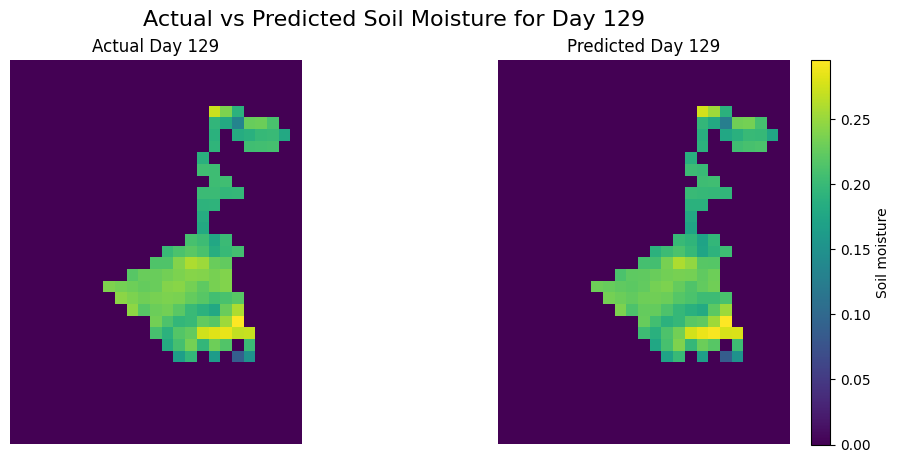

In [7]:
#plot predicted[124][0] and actual[124][0] as 2d viridis
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(actual[0][0], cmap="viridis")
plt.title("Actual Day 129") 
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(predicted[0][0], cmap="viridis")
plt.title("Predicted Day 129")
plt.axis("off")
plt.colorbar(label="Soil moisture")
plt.suptitle("Actual vs Predicted Soil Moisture for Day 129", fontsize=16)
plt.show()

1. Lead time to 7
2. Spatial Attention
3. Contingency table
4. Plot of R2 wrto the lead time
5. Transformer Model
